In [3]:
# Install missing libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [5]:
# Load dataset
df = pd.read_csv('amazon_prime_titles.csv')

# Display first few rows
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [6]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Handle missing values (fill or drop)
df.fillna("Unknown", inplace=True)

# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Convert categorical columns to lowercase for consistency
df['type'] = df['type'].str.lower()
df['rating'] = df['rating'].str.lower()

# Check updated data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       9668 non-null   object        
 1   type          9668 non-null   object        
 2   title         9668 non-null   object        
 3   director      9668 non-null   object        
 4   cast          9668 non-null   object        
 5   country       9668 non-null   object        
 6   date_added    155 non-null    datetime64[ns]
 7   release_year  9668 non-null   int64         
 8   rating        9668 non-null   object        
 9   duration      9668 non-null   object        
 10  listed_in     9668 non-null   object        
 11  description   9668 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 906.5+ KB


<ipython-input-7-5a5c4c86e508>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='coolwarm')


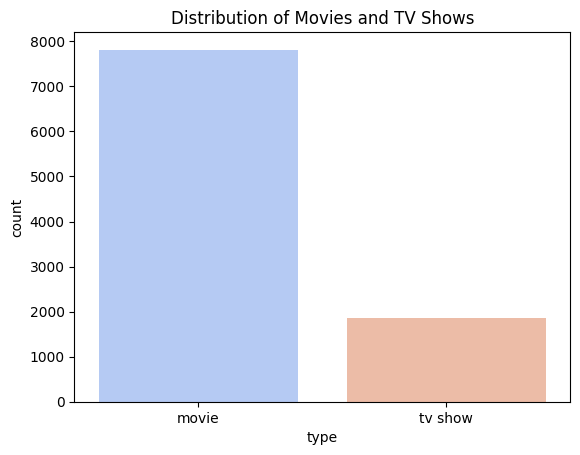

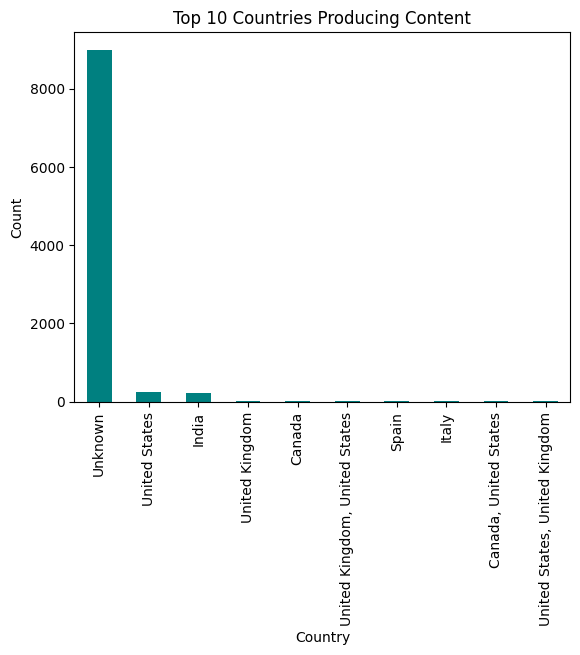

In [7]:
# Count of movie vs TV show
sns.countplot(x='type', data=df, palette='coolwarm')
plt.title("Distribution of Movies and TV Shows")
plt.show()

# Top 10 countries with most content
df['country'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()


In [8]:
# Encode categorical columns
label_enc = LabelEncoder()
df['type'] = label_enc.fit_transform(df['type'])  # Movie = 1, TV Show = 0
df['rating'] = label_enc.fit_transform(df['rating'])

# Create new feature: Content Age (Years since release)
df['content_age'] = 2024 - df['release_year']

# Check updated dataset
df[['type', 'rating', 'content_age']].head()


,type,rating,content_age
0,0,23,10
1,0,0,6
2,0,23,7
3,0,23,10
4,0,23,35


In [9]:
# Select features and target
X = df[['release_year', 'rating', 'content_age']]
y = df['type']

# Split into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8810754912099276
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1550
           1       0.97      0.41      0.58       384

    accuracy                           0.88      1934
   macro avg       0.92      0.71      0.76      1934
weighted avg       0.89      0.88      0.86      1934



In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Convert descriptions to lowercase
df['description'] = df['description'].fillna("").str.lower()

# Apply TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Function to recommend movies
def recommend(title):
    index = df[df['title'].str.lower() == title.lower()].index
    if len(index) == 0:
        return "Title not found!"
    index = index[0]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]  # Top 5 similar
    movie_indices = [i[0] for i in sim_scores]

    return df.iloc[movie_indices][['title', 'type', 'description']]

# Example: Recommend movies similar to "Inception"
recommend("The Secret Life of Us")


,title,type,description
418,The Time Of Our Lives,1,"the time of our lives is a drama series, set i..."
9449,Ide Antaranga Shuddhi,0,four unconnected journeys of different charact...
5592,Dubsmash,0,dubsmash is a movie revolving around the lives...
8126,JARRETTS,1,jarrett is a comedic tv series about nothing g...
7668,Mulberry Street,0,the city that never sleeps may shut its eyes f...
